In [7]:
!pip install pandas numpy matplotlib seaborn openpyxl

In [8]:
import pandas as pd
df = pd.read_csv("D:/Coding/DA projects/Airport_Operations/dataset/Airlines.csv")

In [9]:
df.head()

,id,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
0,1,CO,269,SFO,IAH,3,15,205,1
1,2,US,1558,PHX,CLT,3,15,222,1
2,3,AA,2400,LAX,DFW,3,20,165,1
3,4,AA,2466,SFO,DFW,3,20,195,1
4,5,AS,108,ANC,SEA,3,30,202,0


In [10]:
df.shape

(539383, 9)

In [11]:
df.columns

Index(['id', 'Airline', 'Flight', 'AirportFrom', 'AirportTo', 'DayOfWeek',
       'Time', 'Length', 'Delay'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 539383 entries, 0 to 539382
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           539383 non-null  int64 
 1   Airline      539383 non-null  object
 2   Flight       539383 non-null  int64 
 3   AirportFrom  539383 non-null  object
 4   AirportTo    539383 non-null  object
 5   DayOfWeek    539383 non-null  int64 
 6   Time         539383 non-null  int64 
 7   Length       539383 non-null  int64 
 8   Delay        539383 non-null  int64 
dtypes: int64(6), object(3)
memory usage: 37.0+ MB


In [13]:
df.describe()

,id,Flight,DayOfWeek,Time,Length,Delay
count,539383.00000,539383.000000,539383.000000,539383.000000,539383.000000,539383.000000
mean,269692.00000,2427.928630,3.929668,802.728963,132.202007,0.445442
std,155706.60446,2067.429837,1.914664,278.045911,70.117016,0.497015
min,1.00000,1.000000,1.000000,10.000000,0.000000,0.000000
25%,134846.50000,712.000000,2.000000,565.000000,81.000000,0.000000
50%,269692.00000,1809.000000,4.000000,795.000000,115.000000,0.000000
75%,404537.50000,3745.000000,5.000000,1035.000000,162.000000,1.000000
max,539383.00000,7814.000000,7.000000,1439.000000,655.000000,1.000000


In [14]:
#Check missing values
print(df.isnull().sum())

id             0
Airline        0
Flight         0
AirportFrom    0
AirportTo      0
DayOfWeek      0
Time           0
Length         0
Delay          0
dtype: int64


In [15]:
#Check duplicates
print("Duplicates:",df.duplicated().sum())

Duplicates: 0


In [16]:
#Remove duplicates
df.drop_duplicates(inplace=True)

In [17]:
#Handle missing values
df.fillna(0,inplace=True)

In [18]:
#Check data types
print(df.dtypes)

id              int64
Airline        object
Flight          int64
AirportFrom    object
AirportTo      object
DayOfWeek       int64
Time            int64
Length          int64
Delay           int64
dtype: object


In [27]:
#EDA
#Total Flights
print("Total Flights:",len(df))

Total Flights: 539383


In [28]:
#Total Airlines
print("Total Airlines:",df['Airline'].nunique())

Total Airlines: 18


In [29]:
#Delay Percentage
delay_percentage = (df['Delay'].sum()/len(df))*100
print("Delay Percentage:",round(delay_percentage,2),"%")

Delay Percentage: 44.54 %


In [30]:
# Most Delayed Airlines
airline_delay = df.groupby('Airline')['Delay'].mean().sort_values(ascending=False)

print(airline_delay.head(10))

Airline
WN    0.697759
CO    0.566199
B6    0.467038
OO    0.452899
DL    0.450476
F9    0.449040
EV    0.402208
9E    0.397660
AA    0.388470
XE    0.378944
Name: Delay, dtype: float64


In [31]:
#Delays by Day
day_delay = df.groupby('DayOfWeek')['Delay'].mean()
print(day_delay)


DayOfWeek
1    0.467644
2    0.447337
3    0.470818
4    0.451025
5    0.416608
6    0.400553
7    0.453541
Name: Delay, dtype: float64


In [32]:
#Busiest Airports
print(df['AirportFrom'].value_counts().head(10))

AirportFrom
ATL    34449
ORD    24822
DFW    22154
DEN    19843
LAX    16657
IAH    15821
PHX    15557
DTW    13136
LAS    11918
SFO    11786
Name: count, dtype: int64


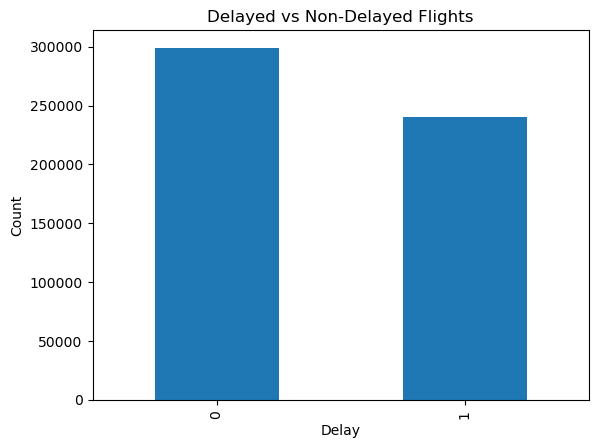

In [35]:
# Data Visualization
# Delay vs Non-Delay

import matplotlib.pyplot as plt

df['Delay'].value_counts().plot(kind='bar')

plt.title('Delayed vs Non-Delayed Flights')
plt.xlabel('Delay')
plt.ylabel('Count')

plt.show()

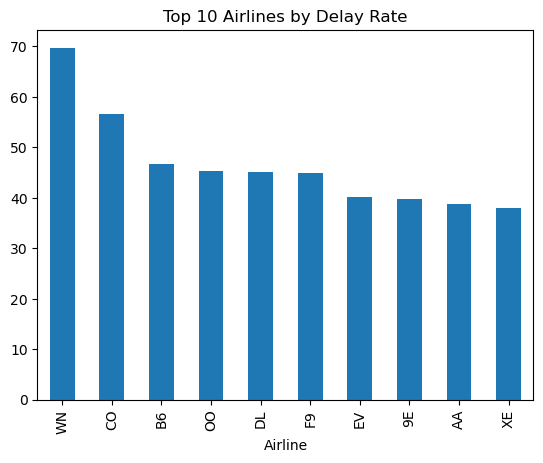

In [36]:
#Top 10 Delayed Airlines
airline_delay = df.groupby('Airline')['Delay'].mean()*100
airline_delay.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 Airlines by Delay Rate')
plt.show()

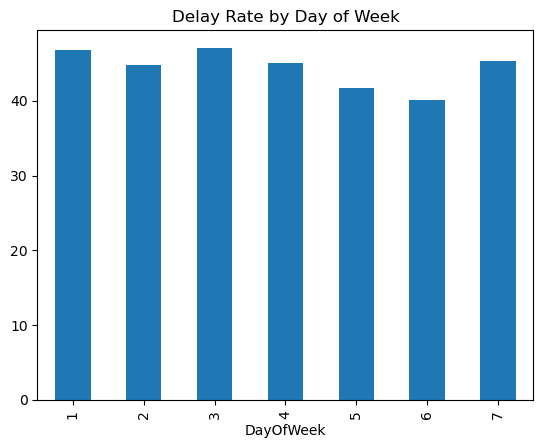

In [37]:
#Delays by Day of Week
day_delay = df.groupby('DayOfWeek')['Delay'].mean()*100
day_delay.plot(kind='bar')
plt.title('Delay Rate by Day of Week')
plt.show()

In [38]:
#Save clean dataset
df.to_csv('cleaned_airlines.csv',index=False)

In [40]:
#Check if the file was saved.
import os

if os.path.exists('cleaned_airlines.csv'):
    print("File saved successfully!")
else:
    print("File not found!")

File saved successfully!


In [42]:
!pip install pandas mysql-connector-python sqlalchemy

In [43]:
import pandas as pd
from sqlalchemy import create_engine

In [48]:
# Create engine to connect to MySQL database
from urllib.parse import quote_plus
from sqlalchemy import create_engine

username = "root"
password = quote_plus("HA02@amanda")
host = "localhost"
database = "flight_analysis"

engine = create_engine(
    f"mysql+mysqlconnector://{username}:{password}@{host}/{database}"
)

In [49]:
# Test connection
with engine.connect() as conn:
    print("Connected Successfully!")

Connected Successfully!


In [50]:
# Upload data to cleaned_flights_data table
df.to_sql(
    'cleaned_flights_data',
    con=engine,
    if_exists='replace',   
    index=False
)

print("Data uploaded successfully!")

Data uploaded successfully!
